# ROC-Based Predictive Analysis: 30-Day Price Movement Classification
## XGBoost Classifier

This notebook implements a supervised machine learning workflow to predict 30-day NVDA price movements using XGBoost.

**Data source:** `model_data.csv` — pre-processed by `DataPipeline.ipynb`  
- Cleaning, feature engineering, multicollinearity reduction, and target variable creation are all handled upstream.
- This notebook loads the ready-to-use dataset and focuses entirely on model training and evaluation.

**Target:** `Price_Direction_30d`
- `1` = Positive 30-day forward ROC (price goes up)
- `0` = Non-positive 30-day forward ROC (price flat or down)


## Initial imports and basic settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 10000 else f'{x:.0f}')
sns.set_style("whitegrid")


## Load data from shared pipeline

Cleaning, feature selection, and target engineering are already done in `DataPipeline.ipynb`.  
No additional preprocessing needed here.


In [3]:
df = pd.read_csv('model_data.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"NaN values : {df.isna().sum().sum()}")
df.head()


Shape      : (6479, 11)
Date range : 1999-04-05 → 2024-12-31
NaN values : 0


,Date,MACD_Signal,BB_Width,RSI_lag1,ATR_Pct,SMA20_Dist,Stoch_K,ROC_roll5_mean,Volume_Ratio,CCI,Price_Direction_30d
0,1999-04-05,0.0000,0.1659,53.2676,0.0708,-0.0356,59.0079,-0.7949,1.0968,-2430.1594,1
1,1999-04-06,-0.0000,0.1711,50.3047,0.0716,-0.0553,43.7114,-3.0706,0.7777,-2246.2156,1
2,1999-04-07,-0.0000,0.1579,48.0056,0.0673,0.0266,48.0843,-2.4571,1.0271,-2462.7682,1
3,1999-04-08,-0.0000,0.1537,55.1791,0.0652,0.0457,61.1985,-1.3578,1.5934,-2537.5295,0
4,1999-04-09,0.0000,0.1550,56.6647,0.0637,0.0267,75.4039,0.6640,0.5975,-2526.1455,0


In [4]:
print("Features in dataset:")
feature_cols = [c for c in df.columns if c not in ['Date', 'Price_Direction_30d']]
for f in feature_cols:
    print(f"  {f}")
print(f"\nTotal features: {len(feature_cols)}")


Features in dataset:
  MACD_Signal
  BB_Width
  RSI_lag1
  ATR_Pct
  SMA20_Dist
  Stoch_K
  ROC_roll5_mean
  Volume_Ratio
  CCI

Total features: 9


## Correlation analysis

Correlation of each selected feature with the target variable.

Correlation with Target (Price_Direction_30d):
  Stoch_K                  0.0317
  RSI_lag1                 0.0216
  SMA20_Dist               0.0139
  ROC_roll5_mean           0.0071
  Volume_Ratio            -0.0018
  MACD_Signal             -0.0233
  CCI                     -0.0333
  ATR_Pct                 -0.0395
  BB_Width                -0.0464


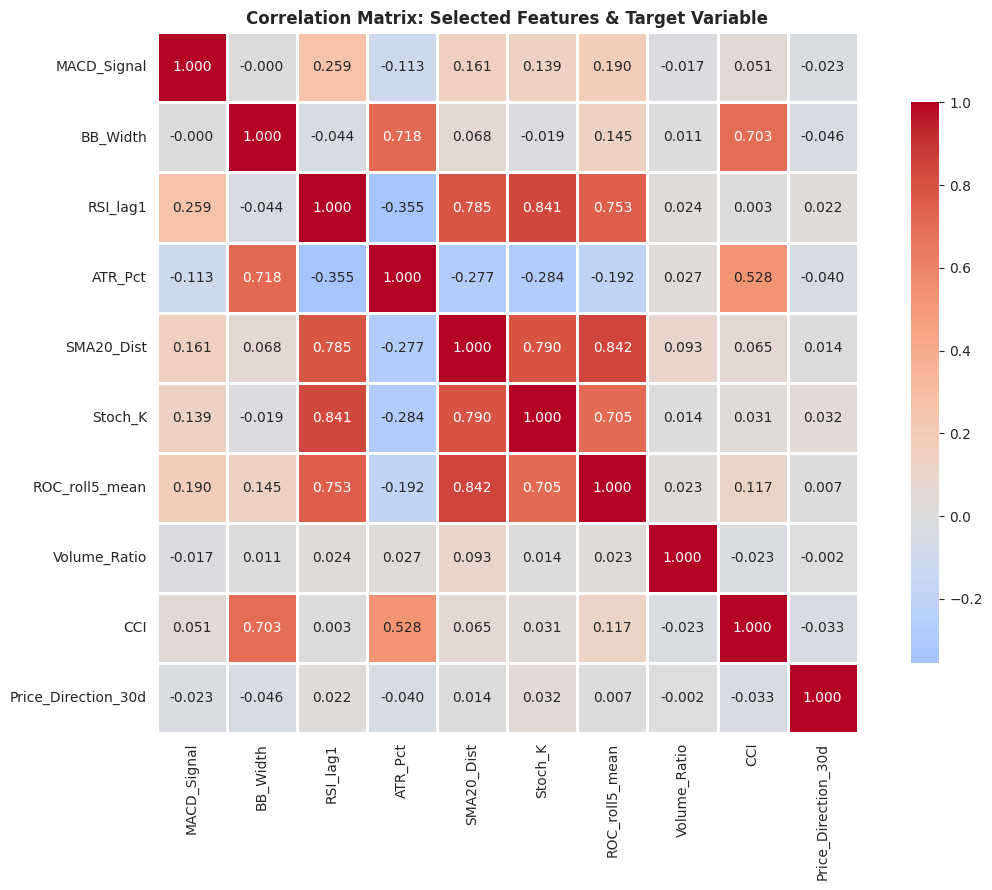

In [5]:
FEATURES = ['MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct',
            'SMA20_Dist', 'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI']
TARGET   = 'Price_Direction_30d'

correlation_matrix = df[FEATURES + [TARGET]].corr()

target_corr = correlation_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print(f"Correlation with Target ({TARGET}):")
for feature, corr_value in target_corr.items():
    print(f"  {feature:<20} {corr_value:>10.4f}")

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Selected Features & Target Variable', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## ROC descriptive statistics

In [8]:
roc = df['ROC_roll5_mean'].dropna()
print("=" * 80)
print("ROC_roll5_mean STATISTICAL ANALYSIS")
print("=" * 80)
print(f"\nTotal observations: {len(roc)}")
print(f"\n{'Metric':<25} {'Value':<15}")
print("-" * 40)
for label, val in [
    ('Mean',     roc.mean()),
    ('Median',   roc.median()),
    ('Std Dev',  roc.std()),
    ('Skewness', roc.skew()),
    ('Kurtosis', roc.kurtosis()),
    ('Min',      roc.min()),
    ('Max',      roc.max()),
    ('IQR',      roc.quantile(0.75) - roc.quantile(0.25)),
]:
    print(f"  {label:<23} {val:<15.4f}")


ROC_roll5_mean STATISTICAL ANALYSIS

Total observations: 6479

Metric                    Value          
----------------------------------------
  Mean                    2.3372         
  Median                  1.9058         
  Std Dev                 12.1680        
  Skewness                0.5811         
  Kurtosis                3.5479         
  Min                     -51.8511       
  Max                     82.9668        
  IQR                     12.8948        


## XGBoost Classifier — Model Training & Evaluation

In [9]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)

X = df[FEATURES]
y = df[TARGET]

print("=" * 80)
print("DATA PREPARATION FOR XGBOOST")
print("=" * 80)
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape  : {y.shape}")
print(f"Features used : {len(FEATURES)}")
print(f"Total samples : {len(df)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain/Test Split:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size : {X_test.shape[0]} samples")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True) * 100}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True) * 100}")


DATA PREPARATION FOR XGBOOST

Features shape: (6479, 9)
Target shape  : (6479,)
Features used : 9
Total samples : 6479

Train/Test Split:
Training set size: 5183 samples
Testing set size : 1296 samples
Train target distribution:
Price_Direction_30d
1   57.3220
0   42.6780
Name: proportion, dtype: float64

Test target distribution:
Price_Direction_30d
1   57.3302
0   42.6698
Name: proportion, dtype: float64


In [10]:
# Hyperparameter tuning with RandomizedSearchCV
xgb_base = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 6, 8],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10, 15],
    'reg_alpha':        [0, 0.1, 0.3, 0.5],
    'reg_lambda':       [1, 1.5, 2.0],
    'scale_pos_weight': [1, (y_train==0).sum()/(y_train==1).sum()]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\nBest Parameters:")
print(xgb_search.best_params_)

y_pred_train = best_xgb.predict(X_train)
y_pred_test  = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\nTest Performance:")
print(classification_report(y_test, y_pred_test))


Fitting 3 folds for each of 30 candidates, totalling 90 fits



Best Parameters:
{'subsample': 0.7, 'scale_pos_weight': 1, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

Test Performance:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       553
           1       0.58      1.00      0.73       743

    accuracy                           0.58      1296
   macro avg       0.79      0.51      0.38      1296
weighted avg       0.76      0.58      0.43      1296



In [11]:
print("=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

train_accuracy  = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall    = recall_score(y_train, y_pred_train)
train_f1        = f1_score(y_train, y_pred_train)

test_accuracy   = accuracy_score(y_test, y_pred_test)
test_precision  = precision_score(y_test, y_pred_test)
test_recall     = recall_score(y_test, y_pred_test)
test_f1         = f1_score(y_test, y_pred_test)
test_roc_auc    = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'Metric':<20} {'Training':<15} {'Testing':<15}")
print("-" * 50)
print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Precision':<20} {train_precision:<15.4f} {test_precision:<15.4f}")
print(f"{'Recall':<20} {train_recall:<15.4f} {test_recall:<15.4f}")
print(f"{'F1-Score':<20} {train_f1:<15.4f} {test_f1:<15.4f}")
print(f"{'ROC-AUC':<20} {'N/A':<15} {test_roc_auc:<15.4f}")

print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("=" * 80)
print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))

print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)
overfitting_gap = train_accuracy - test_accuracy
print(f"Accuracy gap (Train - Test): {overfitting_gap:.4f}")


MODEL PERFORMANCE METRICS

Metric               Training        Testing        
--------------------------------------------------
Accuracy             0.5761          0.5779         
Precision            0.5749          0.5760         
Recall               1.0000          1.0000         
F1-Score             0.7301          0.7309         
ROC-AUC              N/A             0.6094         

DETAILED CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    Negative       1.00      0.01      0.02       553
    Positive       0.58      1.00      0.73       743

    accuracy                           0.58      1296
   macro avg       0.79      0.51      0.38      1296
weighted avg       0.76      0.58      0.43      1296


OVERFITTING ANALYSIS
Accuracy gap (Train - Test): -0.0018


FEATURE IMPORTANCE

Top 10 Most Important Features:
       Feature  Importance
       ATR_Pct      0.1570
   MACD_Signal      0.1406
    SMA20_Dist      0.1178
      RSI_lag1      0.1120
           CCI      0.1055
      BB_Width      0.1030
       Stoch_K      0.0932
ROC_roll5_mean      0.0922
  Volume_Ratio      0.0788


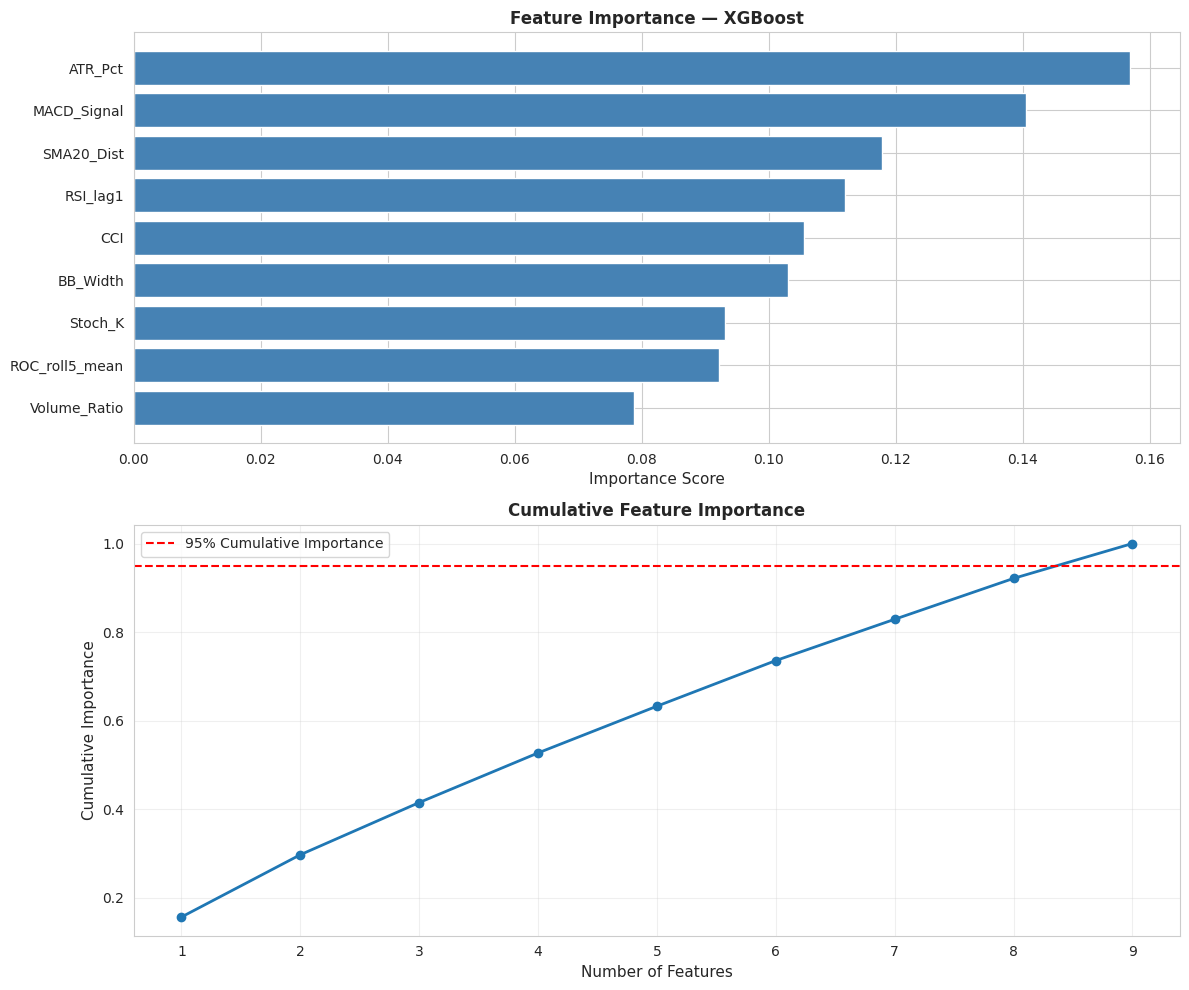


Number of features for 95% cumulative importance: 9


In [12]:
print("=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

feature_importance = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Feature Importance — XGBoost', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()

cumsum_importance = feature_importance['Importance'].cumsum()
axes[1].plot(range(1, len(cumsum_importance) + 1), cumsum_importance.values,
             marker='o', linestyle='-', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% Cumulative Importance')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

n_features_95 = (cumsum_importance >= 0.95).argmax() + 1
print(f"\nNumber of features for 95% cumulative importance: {n_features_95}")


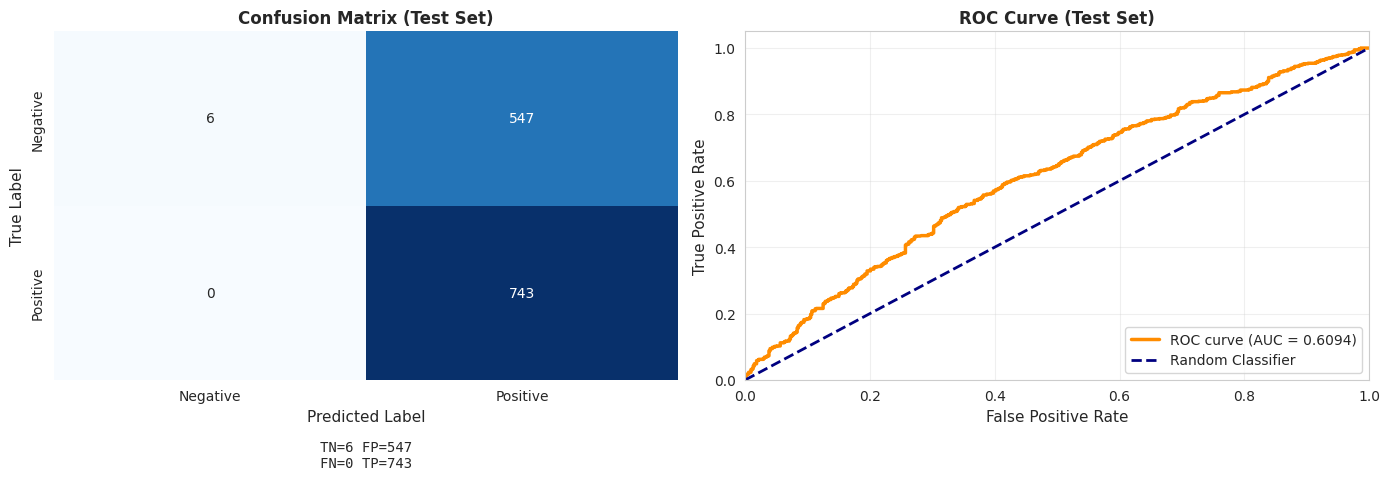

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold', fontsize=12)

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.25, f'TN={tn} FP={fp}\nFN={fn} TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=10, family='monospace')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold', fontsize=12)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
print("=" * 80)
print("MODEL SUMMARY & PREDICTIONS")
print("=" * 80)

predictions_df = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred_test,
    'Probability': y_pred_proba,
    'Correct':     y_test.values == y_pred_test
})

print(f"\nTotal Test Predictions: {len(predictions_df)}")
print(f"Correct Predictions   : {predictions_df['Correct'].sum()}")
print(f"Incorrect Predictions : {(~predictions_df['Correct']).sum()}")

print("\nRecent Predictions (Last 10 samples):")
print(predictions_df.tail(10).to_string())

print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 80)
high_confidence = (predictions_df['Probability'] >= 0.7) | (predictions_df['Probability'] <= 0.3)
print(f"\nHigh Confidence Predictions (prob >= 0.7 or <= 0.3): {high_confidence.sum()} ({high_confidence.sum()/len(predictions_df)*100:.1f}%)")
print(f"Low Confidence Predictions  (0.3 < prob < 0.7)     : {(~high_confidence).sum()} ({(~high_confidence).sum()/len(predictions_df)*100:.1f}%)")

print("\n✓ XGBoost model complete!")
print("\n" + "=" * 80)
print("KEY TAKEAWAYS")
print("=" * 80)
print(f"• Model Accuracy : {test_accuracy:.2%}")
print(f"• ROC-AUC Score  : {test_roc_auc:.4f}")
print(f"• Top Predictor  : {feature_importance.iloc[0]['Feature']} (importance: {feature_importance.iloc[0]['Importance']:.4f})")
print(f"• Class Balance  : {y_test.value_counts(normalize=True)[1]:.1%} positive signals in test set")
print("=" * 80)


MODEL SUMMARY & PREDICTIONS

Total Test Predictions: 1296
Correct Predictions   : 749
Incorrect Predictions : 547

Recent Predictions (Last 10 samples):
      Actual  Predicted  Probability  Correct
1286       0          1       0.5691    False
1287       0          1       0.5810    False
1288       0          1       0.5963    False
1289       1          1       0.5902     True
1290       1          1       0.6087     True
1291       1          1       0.6191     True
1292       1          1       0.6151     True
1293       1          1       0.5786     True
1294       1          1       0.5538     True
1295       0          1       0.5501    False

PREDICTION CONFIDENCE ANALYSIS

High Confidence Predictions (prob >= 0.7 or <= 0.3): 0 (0.0%)
Low Confidence Predictions  (0.3 < prob < 0.7)     : 1296 (100.0%)

✓ XGBoost model complete!

KEY TAKEAWAYS
• Model Accuracy : 57.79%
• ROC-AUC Score  : 0.6094
• Top Predictor  : ATR_Pct (importance: 0.1570)
• Class Balance  : 57.3% positive sig